# Olist 브라질 전자상거래 데이터분석
## 프로젝트 개요
- Olist Store 데이터셋은 2016년부터 2018년까지 브라질 여러 온라인 마켓플레이스에서 발생한 약 10만 건의 실제 주문 데이터를 포함하고 있습니다.
- 주문 상태, 제품 가격, 결제 방식, 운송 실적부터 고객 위치, 제품 카테고리, 고객 리뷰까지 **전자상거래의 전 과정을 다층적으로 관찰할 수 있는 데이터**입니다.
- 또한, 각 주문에 대한 위치 정보(우편번호, 위도/경도)도 제공되어 지역별 분석과 지도 시각화까지 가능하며, 마케팅 퍼널 데이터셋과 결합하여 캠페인 전략까지 탐구할 수 있습니다.

### 데이터 셋 구성
- **olist_customers_dataset** : 고객 데이터셋
- **olist_geolocation_dataset** : 지리 위치 데이터셋
- **olist_order_itmes_dataset** : 주문 항목 데이터셋
- **olist_order_payments_dataset** : 결제 데이터셋
- **olist_order_reviews_dataset** : 주문 리뷰 데이터셋
- **olist_orders_dataset** : 주문 데이터셋
- **olist_products_Dataset** : 제품 데이터셋
- **olist_sellers_dataset** : 판매자 데이터셋
- **product_category_name_translation** : 제품 카테고리 이름을 영어로 번역한다.

## 비즈니스 문제 정의
### 비즈니스 목표
- 브라질 중소 판매자들이 온라인 시장에 진입하고 성장할 수 있도록 지원하는 역할을 한다.
### 수익 모델
- 판매 수수료: 판매당 약 20% 수수료 부과
- 멀티채널 통합 플랫폼 제공 : Mercado Livre, Amazon, Americanas 등 브라질 주요 마켓플레이스와 연동되는 단일 플랫폼 제공
### 주요 기능 및 장점
- 주요 마켓 플레이스와 협업하여 상품의 다양한 노출 및 높은 신뢰도를 확보
- 제품의 가격 경쟁력 및 판매 효율성을 향상시킨다.
- 물류 및 배송을 지원한다.

## 분석 주제
**배송 지연 예측 기반 고객 만족도 관리 시스템**

## 주요 질문
**"배송 서비스 품질을 높여서 고객 만족도 관리를 할 수 있을까?"**

### 분석 목표
- 배송 지연 가능성이 높은 주문을 사전에 예측하는 모델을 개발한다.
- 지연 위험 주문에 대해 자동 알림 시스템을 구현한다.


---
# 프로젝트 개요 및 환경 설정
## 1. 라이브러리 설치 및 import

In [152]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import numpy as np

from scipy import stats
from scipy.stats import skew, kurtosis

from unidecode import unidecode
import geopandas as gpd
import sys
import os

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) # 모든 컬럼이 다 보인다.
pd.set_option('display.max_rows', 100) # 행 출력 개수 제한

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 2. 데이터 로드

In [153]:
df_customers_real = pd.read_csv("../data/olist_customers_dataset.csv")
df_geolocation_real = pd.read_csv("../data/olist_geolocation_dataset.csv")
df_order_items_real = pd.read_csv("../data/olist_order_items_dataset.csv")
df_order_payments_real = pd.read_csv("../data/olist_order_payments_dataset.csv")
df_order_reviews_real = pd.read_csv("../data/olist_order_reviews_dataset.csv")
df_orders_real = pd.read_csv("../data/olist_orders_dataset.csv")
df_products_real = pd.read_csv("../data/olist_products_dataset.csv")
df_sellers_real = pd.read_csv("../data/olist_sellers_dataset.csv")
df_translation_real = pd.read_csv("../data/product_category_name_translation.csv")

In [154]:
df_customers = df_customers_real.copy()
df_geolocation = df_geolocation_real.copy()
df_order_items = df_order_items_real.copy()
df_order_payments = df_order_payments_real.copy()
df_order_reviews = df_order_reviews_real.copy()
df_orders = df_orders_real.copy()
df_products = df_products_real.copy()
df_sellers = df_sellers_real.copy()
df_translation = df_translation_real.copy()

---
# 데이터 이해
## 1. 데이터 구조 파악

In [155]:
print("\n" + "="*60)
print("Customers 데이터 (고객 정보)")
print(f"Shape: {df_customers.shape}")
print("\n[Data Info]")
df_customers.shape
print("="*60)
df_customers.info()
print("="*60)


Customers 데이터 (고객 정보)
Shape: (99441, 5)

[Data Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [156]:
print("\n" + "="*60)
print("Geolocation 데이터 (지리 위치 정보)")
print(f"Shape: {df_geolocation.shape}")
print("\n[Data Info]")
df_geolocation.shape
print("="*60)
df_geolocation.info()
print("="*60)


Geolocation 데이터 (지리 위치 정보)
Shape: (1000163, 5)

[Data Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [157]:
print("\n" + "="*60)
print("Order_Items 데이터 (주문 항목 정보)")
print(f"Shape: {df_order_items.shape}")
print("\n[Data Info]")
df_order_items.shape
print("="*60)
df_order_items.info()
print("="*60)


Order_Items 데이터 (주문 항목 정보)
Shape: (112650, 7)

[Data Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [158]:
print("\n" + "="*60)
print("Order_Payments 데이터 (결제 데이터 정보)")
print(f"Shape: {df_order_payments.shape}")
print("\n[Data Info]")
df_order_payments.shape
print("="*60)
df_order_payments.info()
print("="*60)


Order_Payments 데이터 (결제 데이터 정보)
Shape: (103886, 5)

[Data Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [159]:
print("\n" + "="*60)
print("Order_Reviews 데이터 (리뷰 정보)")
print(f"Shape: {df_order_reviews.shape}")
print("\n[Data Info]")
df_order_reviews.shape
print("="*60)
df_order_reviews.info()
print("="*60)


Order_Reviews 데이터 (리뷰 정보)
Shape: (99224, 7)

[Data Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [160]:
print("\n" + "="*60)
print("Orders 데이터 (주문 정보)")
print(f"Shape: {df_orders.shape}")
print("\n[Data Info]")
df_orders.shape
print("="*60)
df_orders.info()
print("="*60)


Orders 데이터 (주문 정보)
Shape: (99441, 8)

[Data Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [161]:
print("\n" + "="*60)
print("Products 데이터 (상품 정보)")
print(f"Shape: {df_products.shape}")
print("\n[Data Info]")
df_products.shape
print("="*60)
df_products.info()
print("="*60)


Products 데이터 (상품 정보)
Shape: (32951, 9)

[Data Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [162]:
print("\n" + "="*60)
print("Sellers 데이터 (판매자 정보)")
print(f"Shape: {df_sellers.shape}")
print("\n[Data Info]")
df_sellers.shape
print("="*60)
df_sellers.info()
print("="*60)


Sellers 데이터 (판매자 정보)
Shape: (3095, 4)

[Data Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


## 2. 기초 통계량 확인

In [163]:
print("\n" + "="*60)
print("Customers 기초통계")
print("="*60)
display(df_customers.describe(include='all'))


Customers 기초통계


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [164]:
print("\n" + "="*60)
print("Geolocation 기초통계")
print("="*60)
display(df_geolocation.describe(include='all'))


Geolocation 기초통계


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


In [165]:
print("\n" + "="*60)
print("Items 기초통계")
print("="*60)
display(df_order_items.describe(include='all'))


Items 기초통계


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [166]:
print("\n" + "="*60)
print("Payments 기초통계")
print("="*60)
display(df_order_payments.describe(include='all'))


Payments 기초통계


,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [167]:
print("\n" + "="*60)
print("Reviews 기초통계")
print("="*60)
display(df_order_reviews.describe(include='all'))


Reviews 기초통계


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,7b606b0d57b078384f0b58eac1d41d78,c88b1d1b157a9999ce368f218a407141,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


In [168]:
print("\n" + "="*60)
print("Orders 기초통계")
print("="*60)
display(df_orders.describe(include='all'))


Orders 기초통계


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [169]:
print("\n" + "="*60)
print("Products 기초통계")
print("="*60)
display(df_products.describe(include='all'))


Products 기초통계


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [170]:
print("\n" + "="*60)
print("Sellers 기초통계")
print("="*60)
display(df_sellers.describe(include='all'))


Sellers 기초통계


,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


## 3. 샘플 데이터 확인

In [171]:
tables = {
    "olist_customers_dataset": df_customers,
    "olist_geolocation_dataset": df_geolocation,
    "olist_order_items_dataset": df_order_items,
    "olist_order_payments_dataset": df_order_payments,
    "olist_order_reviews_dataset": df_order_reviews,
    "olist_orders_dataset": df_orders,
    "olist_products_dataset": df_products,
    "olist_sellers_dataset": df_sellers
}

for name, df in tables.items():
    print("\n" + "="*60)
    print(f"[Table Name] : {name}")
    display(df.head())


[Table Name] : olist_customers_dataset


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



[Table Name] : olist_geolocation_dataset


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



[Table Name] : olist_order_items_dataset


...

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



[Table Name] : olist_products_dataset


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



[Table Name] : olist_sellers_dataset


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


# 데이터 전처리


In [172]:
print("\n" + "="*60)
print("중복 데이터 확인")
print("="*60)

# 전체 행 중복 확인
print("\n[전체 행 기준 중복]")
print(f"Customers 중복: {df_customers.duplicated().sum():,}건")
print(f"Geolocation 중복: {df_geolocation.duplicated().sum():,}건")
print(f"Order_items 중복: {df_order_items.duplicated().sum():,}건")
print(f"Order_payments 중복: {df_order_payments.duplicated().sum():,}건")
print(f"Order_reviews 중복: {df_order_reviews.duplicated().sum():,}건")
print(f"Orders 중복: {df_orders.duplicated().sum():,}건")
print(f"Products 중복: {df_products.duplicated().sum():,}건")
print(f"Sellers 중복: {df_sellers.duplicated().sum():,}건")
print(f"Category 중복: {df_translation.duplicated().sum():,}건")

# # ID 기준 중복 확인
# print("\n[ID 기준 중복]")

# print(f"Customers(customer_id) 중복: {df_customers.duplicated(subset=['customer_id']).sum():,}건")

# # print(f"Order_items 중복: {df_order_items.duplicated().sum():,}건")
# # print(f"Order_payments 중복: {df_order_payments.duplicated().sum():,}건")

# print(f"Order_reviews 중복: {df_order_reviews.duplicated(subset=['order_id']).sum():,}건")

# print(f"Orders 중복: {df_orders.duplicated(subset=['order_id']).sum():,}건")
# print(f"Orders 중복: {df_orders.duplicated(subset=['customer_id']).sum():,}건")

# print(f"Products 중복: {df_products.duplicated(subset=['product_id']).sum():,}건")

# print(f"Sellers 중복: {df_sellers.duplicated(subset=['seller_id']).sum():,}건")

# print(f"Geolocation 중복: {df_geolocation.duplicated(subset=['geolocation_zip_code_prefix']).sum():,}건")



중복 데이터 확인

[전체 행 기준 중복]
Customers 중복: 0건
Geolocation 중복: 261,831건
Order_items 중복: 0건
Order_payments 중복: 0건
Order_reviews 중복: 0건
Orders 중복: 0건
Products 중복: 0건
Sellers 중복: 0건
Category 중복: 0건


## 데이터 타입 변환

In [173]:
# to_datetime

# MS
df_order_items['shipping_limit_date'] = pd.to_datetime(df_order_items['shipping_limit_date'])


In [174]:
# DH
df_orders['order_estimated_delivery_date'] = pd.to_datetime(
    df_orders['order_estimated_delivery_date'], 
    format='%Y-%m-%d %H:%M:%S'
)
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

cols_na = [
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date"
]

df_orders[cols_na] = df_orders[cols_na].apply(
    pd.to_datetime,
    errors="coerce"
)

In [175]:
# HR
df_order_reviews['review_creation_date']    = pd.to_datetime(df_order_reviews['review_creation_date'])
df_order_reviews['review_answer_timestamp'] = pd.to_datetime(df_order_reviews['review_answer_timestamp'])

## 컬럼명 정제

In [176]:
# MS
df_customers.columns = df_customers.columns.str.lower().str.strip()
df_geolocation.columns = df_geolocation.columns.str.lower().str.strip()
df_order_items.columns = df_order_items.columns.str.lower().str.strip()
df_order_payments.columns = df_order_payments.columns.str.lower().str.strip()
df_order_reviews.columns = df_order_reviews.columns.str.lower().str.strip()
df_orders.columns = df_orders.columns.str.lower().str.strip()
df_products.columns = df_products.columns.str.lower().str.strip()
df_sellers.columns = df_sellers.columns.str.lower().str.strip()
df_translation = df_translation.columns.str.lower().str.strip()


In [177]:
# DH
#데이터 정제- 불필요 행 제거

#order_status 칼럼 - 결측X, 분석 목표인 배달 요소와 관련 없는 status 분리하여 분석 진행이 용이할 것으로 판단
#'배송 품질' 일단 Olist와 직결된 물류 배송에 국한하여 정의/ 상품 준비단계에서 소요되는 날짜 논외
core_statuses = ['delivered', 'shipped', 'canceled']
df_orders = df_orders[df_orders['order_status'].isin(core_statuses)]


In [178]:
# HR
# review_comment_title, review_comment_message 컬럼 제거

df_order_reviews_clean = df_order_reviews.drop(
    columns=['review_comment_title', 'review_comment_message']
)
print(df_order_reviews_clean.columns.tolist())

['review_id', 'order_id', 'review_score', 'review_creation_date', 'review_answer_timestamp']


## 결측치 처리

In [179]:
# MS
print("\n" + "="*60)
print("결측치 확인")
print("="*60)

for name,table in tables.items():
    missing_df = pd.DataFrame({
        '결측수' : table.isnull().sum(),
        '결측비율(%)' : (table.isnull().sum() / len(table) * 100).round(2)
    })
    missing_df = missing_df[missing_df['결측수']>0].sort_values('결측수',ascending=False)

    print(name)
    if len(missing_df) > 0:
        print("[결측치 현황]")
        display(missing_df)
        print("\n")
    else:
        print(f"결측치 없음\n")


결측치 확인
olist_customers_dataset
결측치 없음

olist_geolocation_dataset
결측치 없음

olist_order_items_dataset
결측치 없음

olist_order_payments_dataset
결측치 없음

olist_order_reviews_dataset
[결측치 현황]


,결측수,결측비율(%)
review_comment_title,87656,88.34
review_comment_message,58247,58.70




olist_orders_dataset
[결측치 현황]


,결측수,결측비율(%)
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16




olist_products_dataset
[결측치 현황]


,결측수,결측비율(%)
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01




olist_sellers_dataset
결측치 없음



In [180]:
# YH
# 2개의 결측치는 무시하기로 판단 -> drop
df_products = df_products.dropna(subset=['product_weight_g'])
df_products = df_products.dropna(subset=['product_length_cm'])
df_products = df_products.dropna(subset=['product_height_cm'])
df_products = df_products.dropna(subset=['product_width_cm'])

print(df_products['product_weight_g'].isna().sum())
print(df_products['product_length_cm'].isna().sum())
print(df_products['product_height_cm'].isna().sum())
print(df_products['product_width_cm'].isna().sum())

0
0
0
0


In [181]:
df_products['product_category_name'] = df_products['product_category_name'].fillna('unknown')

- reviews 테이블 중복 order_id 처리

In [182]:
# reviews 테이블
# 가장 최신 리뷰만 유지 (review_creation_date 기준)
df_order_reviews_clean = (
    df_order_reviews_clean
    .sort_values('review_creation_date')
    .drop_duplicates('order_id', keep='last')  # 마지막(최신) 리뷰만 유지
    .reset_index(drop=True)
)

In [183]:
# DH
# olist_orders_dataset
# 1. 이상치 분리: 
# order_status 'canceled'인데 order_delivered_customer_date 값 있음 #6개 
# >> review message 보니까 제거하면 안되는 case, 새로운 데이터프레임으로 분리 저장
con_0 = (
    (df_orders["order_status"] == "canceled") &
    (df_orders["order_delivered_customer_date"].notna())
)
# order_status 'canceled'인데 order_delivered_customer_date 값 있는 6개 데이터, 분리한 df
df_canceled_with_delivery = df_orders[con_0].copy()

# 2. df_orders에서는 해당 행들 삭제
df_orders = df_orders[~con_0]

# 3. 결과 확인
print(f"분리된 행: {df_canceled_with_delivery.shape[0]}개")
print(f"df_orders 남은 행: {df_orders.shape[0]}개")
print(f"\ndf_canceled_with_delivery:")
print(df_canceled_with_delivery)

df_orders.isnull().sum()

분리된 행: 6개
df_orders 남은 행: 98204개

df_canceled_with_delivery:
                               order_id                       customer_id  \
2921   1950d777989f6a877539f53795b4c3c3  1bccb206de9f0f25adc6871a1bcf77b2   
8791   dabf2b0e35b423f94618bf965fcb7514  5cdec0bb8cbdf53ffc8fdc212cd247c6   
58266  770d331c84e5b214bd9dc70a10b829d0  6c57e6119369185e575b36712766b0ef   
59332  8beb59392e21af5eb9547ae1a9938d06  bf609b5741f71697f65ce3852c5d2623   
92636  65d1e226dfaeb8cdc42f665422522d14  70fc57eeae292675927697fe03ad3ff5   
94399  2c45c33d2f9cb8ff8b1c86cc28c11c30  de4caa97afa80c8eeac2ff4c8da5b72e   

      order_status order_purchase_timestamp   order_approved_at  \
2921      canceled      2018-02-19 19:48:52 2018-02-19 20:56:05   
8791      canceled      2016-10-09 00:56:52 2016-10-09 13:36:58   
58266     canceled      2016-10-07 14:52:30 2016-10-07 15:07:10   
59332     canceled      2016-10-08 20:17:50 2016-10-09 14:34:30   
92636     canceled      2016-10-03 21:01:41 2016-10-04 10:18:57 

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 155
order_delivered_carrier_date      552
order_delivered_customer_date    1734
order_estimated_delivery_date       0
dtype: int64

In [184]:
# 'delivered' 상태 행만 추출
#df_delivered = df_orders[df_orders["order_status"] == "delivered"].copy()
# 조회 확인
# print(df_delivered.head())
# print(df_delivered.isna().sum())
#order_approved_at                14
# order_delivered_carrier_date      2
# order_delivered_customer_date     8

# 결측 처리
# order_status 'delivered', 'order_approved_at'컬럼 결측 대체
# 조건 정의
con_1 = (
    (df_orders['order_status'] == 'delivered') &
    (df_orders['order_approved_at'].isna())
)

# 결측 order_purchase_timestamp로 대체
df_orders.loc[con_1, 'order_approved_at'] = df_orders.loc[con_1, 'order_purchase_timestamp']

# 결과 확인
print(con_1.sum()) #행갯수
print(df_orders.loc[con_1, ['order_approved_at', 'order_purchase_timestamp']].head())

14
        order_approved_at order_purchase_timestamp
5323  2017-02-18 14:40:00      2017-02-18 14:40:00
16567 2017-02-18 12:45:31      2017-02-18 12:45:31
19031 2017-02-18 13:29:47      2017-02-18 13:29:47
22663 2017-02-18 16:48:35      2017-02-18 16:48:35
23156 2017-02-17 13:05:55      2017-02-17 13:05:55


In [185]:
# order_status 'delivered', 'order_delivered_carrier_date'컬럼 결측 대체
# 조건 정의
con_2 = (
    (df_orders['order_status'] == 'delivered') &
    (df_orders['order_delivered_carrier_date'].isna())
)

# 해당 행들만 order_approved_at로 대체
df_orders.loc[con_2, 'order_delivered_carrier_date'] = df_orders.loc[con_2, 'order_approved_at']

# 결과 확인
print(con_2.sum()) #행갯수
print(df_orders.loc[con_2, ['order_delivered_carrier_date', 'order_approved_at']].head())

2
      order_delivered_carrier_date   order_approved_at
73222          2017-09-29 09:07:16 2017-09-29 09:07:16
92643          2017-05-25 23:30:16 2017-05-25 23:30:16


In [186]:
# order_status 'delivered', 'order_delivered_customer_date'컬럼 결측 reviews table 리뷰 작성 날짜로 대체
# df_orders와 df_order_reviews(order_id 기준) 임의 merge
df_orders = df_orders.merge(
    df_order_reviews[['order_id', 'review_creation_date']],
    on='order_id',
    how='left'
)

# review_creation_date datetime 임의 변환
df_orders['review_creation_date'] = pd.to_datetime(df_orders['review_creation_date'], errors='coerce')

# 조건 정의
con_3 = (
    (df_orders['order_status'] == 'delivered') &
    (df_orders['order_delivered_customer_date'].isna())
)

# 결측 채우기
df_orders.loc[con_3, 'order_delivered_customer_date'] = df_orders.loc[con_3, 'review_creation_date']

# merge 후 불필요 컬럼 제거
df_orders = df_orders.drop(columns=['review_creation_date'])

In [187]:
# 조건 정의: shipped 상태 & order_delivered_customer_date 결측 정상_ "2099-01-01 00:00:00" 형태로 대체
con_4= (
    (df_orders['order_status'] == 'shipped') &
    (df_orders['order_delivered_customer_date'].isna())
)

# 정상 결측 값 정의
normal_blank = pd.Timestamp("2099-01-01 00:00:00")

# 결측 대체
df_orders.loc[con_4, 'order_delivered_customer_date'] = normal_blank


In [188]:
# 조건 정의: canceled 상태 & order_delivered_customer_date 결측 정상_ "2099-01-01 00:00:00" 형태로 대체
# 조건: canceled 상태
con_5 = df_orders['order_status'] == 'canceled'

# 결측 처리할 컬럼 리스트
cols_fill= [
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
]

# 한 번에 결측 처리
for col in cols_fill:
    df_orders.loc[con_5 & df_orders[col].isna(), col] = normal_blank

In [189]:
tables = {
    "olist_customers_dataset": df_customers,
    "olist_geolocation_dataset": df_geolocation,
    "olist_order_items_dataset": df_order_items,
    "olist_order_payments_dataset": df_order_payments,
    "olist_order_reviews_dataset": df_order_reviews,
    "olist_orders_dataset": df_orders,
    "olist_products_dataset": df_products,
    "olist_sellers_dataset": df_sellers
}

In [190]:
# MS
print("\n" + "="*60)
print("결측치 확인")
print("="*60)

for name,table in tables.items():
    missing_df = pd.DataFrame({
        '결측수' : table.isnull().sum(),
        '결측비율(%)' : (table.isnull().sum() / len(table) * 100).round(2)
    })
    missing_df = missing_df[missing_df['결측수']>0].sort_values('결측수',ascending=False)

    print(name)
    if len(missing_df) > 0:
        print("[결측치 현황]")
        display(missing_df)
        print("\n")
    else:
        print(f"결측치 없음\n")


결측치 확인
olist_customers_dataset
결측치 없음

olist_geolocation_dataset
결측치 없음

olist_order_items_dataset
결측치 없음

olist_order_payments_dataset
결측치 없음

olist_order_reviews_dataset
[결측치 현황]


,결측수,결측비율(%)
review_comment_title,87656,88.34
review_comment_message,58247,58.70




olist_orders_dataset
결측치 없음

olist_products_dataset
[결측치 현황]


,결측수,결측비율(%)
product_name_lenght,609,1.85
product_description_lenght,609,1.85
product_photos_qty,609,1.85




olist_sellers_dataset
결측치 없음



# ※product_name_lenght/product_description_lenght/product_photos_qty의 경우 결측치 처리가 안되어있는듯..!

## 이상치 처리

In [191]:
# HR
# payments 테이블

df_order_payments = df_order_payments[df_order_payments['payment_type'] != 'not_defined']

In [192]:
# ── 3. 주문별 집계 ──
payments_agg = df_order_payments.groupby('order_id').agg(
    # 주결제 수단 (sequential=1)
    main_payment_type   = ('payment_type', 'first'),
    # 최대 할부 개월수
    max_installments    = ('payment_installments', 'max'),
    # 총 결제 금액
    total_payment_value = ('payment_value', 'sum'),
    # 결제 수단 개수 (쿠폰 많이 쓸수록 높아짐)
    payment_count       = ('payment_sequential', 'max'),
    # 바우처 포함 여부 (보조 수단으로 쓰이는 경우가 많아서 별도 체크)
    has_voucher         = ('payment_type', lambda x: int('voucher' in x.values)),
).reset_index()

# ── 4. 주결제 수단 One-Hot 인코딩 ──
# → pay_credit_card, pay_boleto, pay_voucher, pay_debit_card 컬럼 자동 생성
payments_agg = pd.get_dummies(payments_agg, columns=['main_payment_type'], prefix='pay')
print(f"집계 후 행수: {len(payments_agg):,}")
print(payments_agg.head())
print(payments_agg.columns.tolist())


집계 후 행수: 99,437
                           order_id  max_installments  total_payment_value  \
0  00010242fe8c5a6d1ba2dd792cb16214                 2                72.19   
1  00018f77f2f0320c557190d7a144bdd3                 3               259.83   
2  000229ec398224ef6ca0657da4fc703e                 5               216.87   
3  00024acbcdf0a6daa1e931b038114c75                 2                25.78   
4  00042b26cf59d7ce69dfabb4e55b4fd9                 3               218.04   

   payment_count  has_voucher  pay_boleto  pay_credit_card  pay_debit_card  \
0              1            0       False             True           False   
1              1            0       False             True           False   
2              1            0       False             True           False   
3              1            0       False             True           False   
4              1            0       False             True           False   

   pay_voucher  
0        False  
1        Fal

## 주석처리한 부분 위로 올렸는데 안됨..
- 예상으로는 reviews와 reviews_clean의 차이 아닐까 싶음.

In [193]:
# # reviews 테이블
# # 가장 최신 리뷰만 유지 (review_creation_date 기준)
# df_order_reviews_clean = (
#     df_order_reviews_clean
#     .sort_values('review_creation_date')
#     .drop_duplicates('order_id', keep='last')  # 마지막(최신) 리뷰만 유지
#     .reset_index(drop=True)
# )

In [194]:
# orders 테이블

# ── 이상치 조건 정의 (논리적으로 역전된 경우) ──
cond1 = df_orders['order_purchase_timestamp'] > df_orders['order_approved_at']               # 주문 > 승인
cond2 = df_orders['order_approved_at'] > df_orders['order_delivered_carrier_date']           # 승인 > 출발
cond3 = df_orders['order_delivered_carrier_date'] > df_orders['order_delivered_customer_date'] # 출발 > 수령
cond4 = df_orders['order_purchase_timestamp'] > df_orders['order_delivered_customer_date']   # 주문 > 수령

# 이 컬럼이 미리 있어야 마스크 코드가 작동해요
df_orders['approval_vs_carrier_hours'] = (
    df_orders['order_approved_at'] - df_orders['order_delivered_carrier_date']
).dt.total_seconds() / 3600

mask_0_24h = cond2 & (df_orders['order_status'] == 'delivered') & (df_orders['approval_vs_carrier_hours'] <= 24)
df_orders.loc[mask_0_24h, 'order_approved_at'] = df_orders.loc[mask_0_24h, 'order_delivered_carrier_date']

print(f"보정 완료: {mask_0_24h.sum():,}건")

'''
보정 완료: 897건
'''

mask_over_24h = cond2 & (df_orders['order_status'] == 'delivered') & (df_orders['approval_vs_carrier_hours'] > 24)

print(f"삭제 대상: {mask_over_24h.sum():,}건")
df_orders = df_orders[~mask_over_24h]  
print(f"삭제 후 df_orders: {len(df_orders):,}건")

'''
삭제 대상: 453건
삭제 후 df_orders: 97,751건
'''

df_orders = df_orders.drop(columns=['approval_vs_carrier_hours'])


df_cond2_shipped = df_orders[cond2 & (df_orders['order_status'] == 'shipped')].copy()
print(f"cond2 shipped 건수: {len(df_cond2_shipped):,}건")
shipped_review = df_order_reviews_clean[df_order_reviews_clean['order_id'].isin(df_cond2_shipped['order_id'])]

print("\n=== 평점별 건수 & 리뷰 샘플 ===")
for score in sorted(shipped_review['review_score'].dropna().unique()):
    subset = shipped_review[shipped_review['review_score'] == score]
    print(f"\n[{int(score)}점] {len(subset)}건")

# ── 1~2점: 승인 시각을 배송 출고 시각으로 보정 ──
ids_score_1_2 = shipped_review[shipped_review['review_score'].isin([1, 2])]['order_id']
mask_fix = df_orders['order_id'].isin(ids_score_1_2)

df_orders.loc[mask_fix, 'order_approved_at'] = df_orders.loc[mask_fix, 'order_delivered_carrier_date']
print(f"보정 (1~2점): {mask_fix.sum()}건")

# ── 4~5점: 삭제 ──
ids_score_4_5 = shipped_review[shipped_review['review_score'].isin([4, 5])]['order_id']

print(f"삭제 (4~5점): {len(ids_score_4_5)}건")
df_orders = df_orders[~df_orders['order_id'].isin(ids_score_4_5)]
print(f"삭제 후 df_orders: {len(df_orders):,}건")

'''
보정 (1~2점): 5건
삭제 (4~5점): 2건
삭제 후 df_orders: 97,749건
'''

보정 완료: 899건
삭제 대상: 453건
삭제 후 df_orders: 98,295건
cond2 shipped 건수: 10건

=== 평점별 건수 & 리뷰 샘플 ===

[1점] 3건

[2점] 2건

[4점] 1건

[5점] 1건
보정 (1~2점): 6건
삭제 (4~5점): 2건
삭제 후 df_orders: 98,293건


'\n보정 (1~2점): 5건\n삭제 (4~5점): 2건\n삭제 후 df_orders: 97,749건\n'

In [195]:
# orders 테이블

cond3 = df_orders['order_delivered_carrier_date'] > df_orders['order_delivered_customer_date']

# invalid_df 생성 (cond3 이상치)
invalid_df_3 = df_orders[cond3].copy()

print("\n=== order_status 분포 ===")
print(invalid_df_3['order_status'].value_counts())

# ── 삭제 ──
print(f"\n삭제 대상: {cond3.sum():,}건")
df_orders = df_orders[~cond3]
print(f"삭제 후 df_orders: {len(df_orders):,}건")


=== order_status 분포 ===
order_status
delivered    23
Name: count, dtype: int64

삭제 대상: 23건
삭제 후 df_orders: 98,270건


In [196]:
# YH

# 우편번호별 경도/위도의 차
dup_zip = df_geolocation['geolocation_zip_code_prefix'].duplicated(keep = False)
df_dup = df_geolocation[dup_zip][['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']].sort_values('geolocation_zip_code_prefix')

df_range = df_dup.groupby('geolocation_zip_code_prefix').agg(
    lat_range=('geolocation_lat', lambda x: x.max() - x.min()),
    lng_range=('geolocation_lng', lambda x: x.max() - x.min())
).reset_index()



#시각화(필요 없다면 패스)

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# axes[0].hist(df_range['lat_range'], bins=50)
# axes[0].set_title('우편번호별 위도 차이 분포')
# axes[0].set_xlabel('위도 범위 (degree)')
# axes[0].set_ylabel('우편번호 개수')
# axes[0].set_xlim(0, 5)

# axes[1].hist(df_range['lng_range'], bins=50)
# axes[1].set_title('우편번호별 경도 차이 분포')
# axes[1].set_xlabel('경도 범위 (degree)')
# axes[1].set_ylabel('우편번호 개수')
# axes[1].set_xlim(0, 5)

# plt.tight_layout()
# plt.show()


# #산점도 시각화
# plt.scatter(df_range['lat_range'], df_range['lng_range'], alpha=0.3)
# plt.xlabel('위도 차이 (degree)')
# plt.ylabel('경도 차이 (degree)')
# plt.title('우편번호별 위도/경도 차이')
# plt.show()

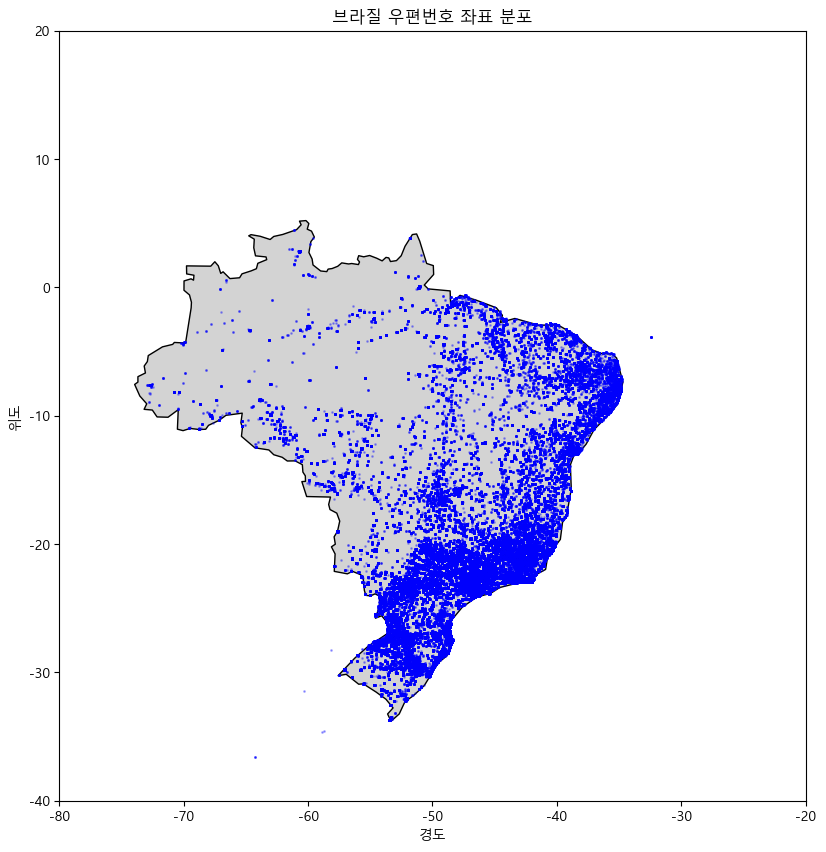

In [197]:
# URL에서 직접 브라질 지도 불러오기
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
brazil = world[world['NAME'] == 'Brazil']

fig, ax = plt.subplots(figsize=(12, 10))

brazil.plot(ax=ax, color='lightgrey', edgecolor='black')

ax.scatter(df_geolocation['geolocation_lng'], df_geolocation['geolocation_lat'],
           s=1, alpha=0.3, color='blue')

ax.set_xlim(-80, -20) #경도 비율 조절
ax.set_ylim(-40, 20) #위도 비율 조절

ax.set_title('브라질 우편번호 좌표 분포')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
plt.show()

In [198]:
# 브라질 권역을 벗어나는 이상치 필터링
#위도(lat) -34~6, 경도(lng) -74.5~-32

df_geolocation = df_geolocation[
    (df_geolocation['geolocation_lng'] < -32) &
    (df_geolocation['geolocation_lng'] > -74.5) &
    (df_geolocation['geolocation_lat'] < 6) &
    (df_geolocation['geolocation_lat'] > -34)
]

#필터링 작동 확인
# -32보다 큰 경도 값 확인
print(df_geolocation[df_geolocation['geolocation_lng'] > -32]['geolocation_lng'])

Series([], Name: geolocation_lng, dtype: float64)


(1000132, 5)
(988050, 5)


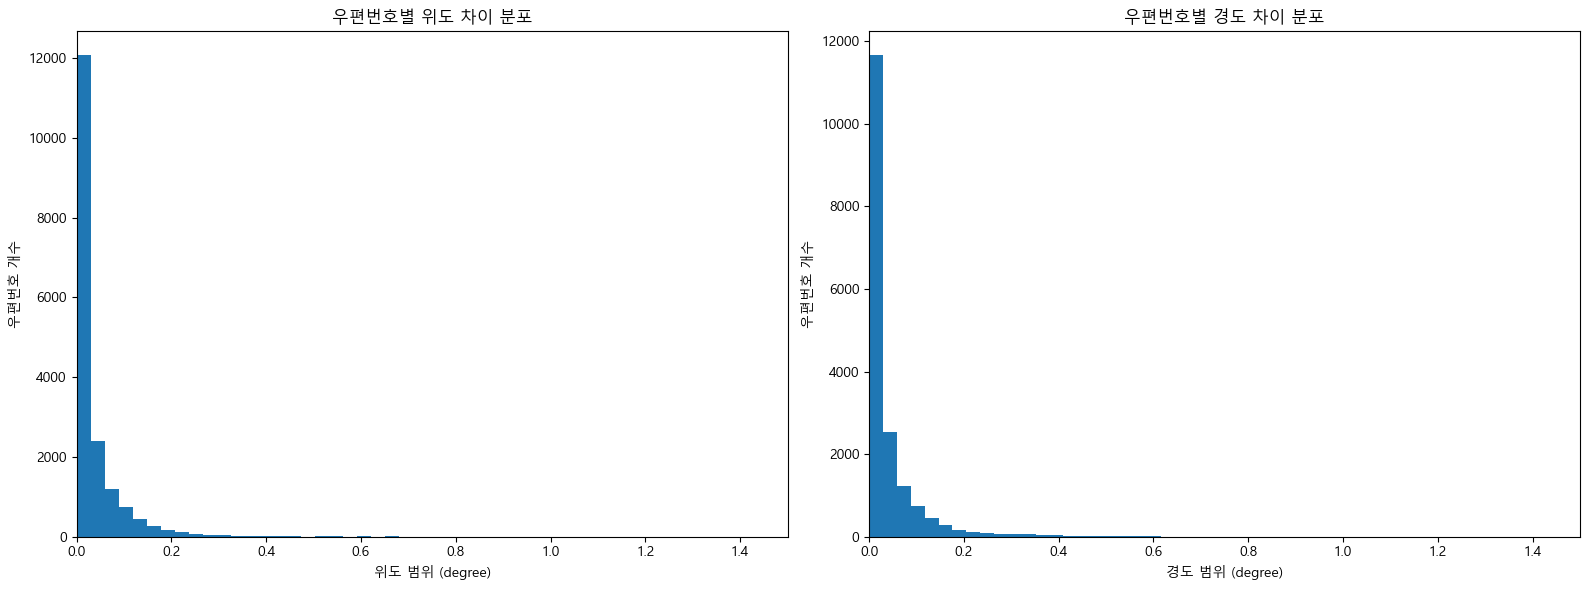

In [199]:
# 같은 우편번호에서 좌표의 차가 1.5가 넘어서는 이상치를 필터링

#필터링 전
print(df_geolocation.shape)
#1000132

df_geolocation = df_geolocation.groupby('geolocation_zip_code_prefix').filter(
    lambda x: (x['geolocation_lat'].max() - x['geolocation_lat'].min() < 1.5) &
              (x['geolocation_lng'].max() - x['geolocation_lng'].min() < 1.5)
)

#필터링 후
print(df_geolocation.shape)
#988050


#시각화
# 필터링 후 df_dup 다시 계산
dup_zip2 = df_geolocation['geolocation_zip_code_prefix'].duplicated(keep=False)
df_dup2 = df_geolocation[dup_zip2][['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']]

df_range2 = df_dup2.groupby('geolocation_zip_code_prefix').agg(
    lat_range=('geolocation_lat', lambda x: x.max() - x.min()),
    lng_range=('geolocation_lng', lambda x: x.max() - x.min())
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df_range2['lat_range'], bins=50)
axes[0].set_title('우편번호별 위도 차이 분포')
axes[0].set_xlabel('위도 범위 (degree)')
axes[0].set_ylabel('우편번호 개수')
axes[0].set_xlim(0, 1.5)

axes[1].hist(df_range2['lng_range'], bins=50)
axes[1].set_title('우편번호별 경도 차이 분포')
axes[1].set_xlabel('경도 범위 (degree)')
axes[1].set_ylabel('우편번호 개수')
axes[1].set_xlim(0, 1.5)

plt.tight_layout()
plt.show()

In [200]:
# city와 state 전처리(공백 제거, 영어 변환, 소문자&대문자)
df_geolocation['geolocation_city'] = df_geolocation['geolocation_city'].str.lower().apply(unidecode).replace(" ", "")
df_geolocation['geolocation_state'] = df_geolocation['geolocation_state'].str.upper().str.replace(" ", "")

#city는 소문자, state는 대문자

In [201]:
# MS

# 데이터셋은 2016-2018까지의 데이터를 다룸
df2020 = df_order_items[df_order_items['shipping_limit_date'].dt.year == 2020]

# seller_city 영어 소문자/공백제거
df_sellers['seller_city'] = df_sellers['seller_city'].str.lower().apply(unidecode)

In [202]:
# 전체 행 중복 확인
print("\n[전체 행 기준 중복]")
print(f"Customers 중복: {df_customers.duplicated().sum():,}건")
print(f"Geolocation 중복: {df_geolocation.duplicated().sum():,}건")
print(f"Order_items 중복: {df_order_items.duplicated().sum():,}건")
print(f"Order_payments 중복: {df_order_payments.duplicated().sum():,}건")
print(f"Order_reviews 중복: {df_order_reviews.duplicated().sum():,}건")
print(f"Orders 중복: {df_orders.duplicated().sum():,}건")
print(f"Products 중복: {df_products.duplicated().sum():,}건")
print(f"Sellers 중복: {df_sellers.duplicated().sum():,}건")
print(f"Category 중복: {df_translation.duplicated().sum():,}건")


[전체 행 기준 중복]
Customers 중복: 0건
Geolocation 중복: 276,569건
Order_items 중복: 0건
Order_payments 중복: 0건
Order_reviews 중복: 0건
Orders 중복: 544건
Products 중복: 0건
Sellers 중복: 0건
Category 중복: 0건


# ※갑자기 Orders에 중복이 왜 생길까요...?